In [23]:
import numpy as np
import tqdm

In [28]:
class HC_Agglomerative():
    def __init__(self, iter: int=100):
        self.X = None;
        self.iter = iter;
        self.assigned_clusters = None;
    
    def distance(self, X, Xt) -> np.float32:
        return np.sqrt(np.sum((X - Xt)**2))
    
    def fit(self, X: np.ndarray):
        if(self.X == None):
            self.X = X;
            self.assigned_clusters = [i for i in range(len(X))]
        
        iter = self.iter

        for _ in tqdm.tqdm(range(iter)):
            clusters = set(self.assigned_clusters)

            min_dst = 100000000;
            c1 = -1;
            c2 = -1;

            for cl_1 in clusters:
                for cl_2 in clusters:
                    dist = 0;
                    for i in range(len(X)):
                        for j in range(len(X)):
                            if(self.assigned_clusters[i] == cl_1 and self.assigned_clusters[j] == cl_2):
                                dist += self.distance(X[i], X[j])
                    if(dist < min_dst):
                        c1 = cl_1;
                        c2 = cl_2
                        min_dst = dist;
            
                for i in range(len(X)):
                    if(self.assigned_clusters[i] == c1): self.assigned_clusters[i] = c2
                    

            iter -= 1;
    
        for i in range(len(self.assigned_clusters)):
            print(self.assigned_clusters[i]);

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.assigned_clusters

In [29]:
model = HC_Agglomerative()

model.fit(X)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [06:45<00:00,  4.06s/it]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [18]:
from sklearn.datasets import make_blobs

# X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=0)

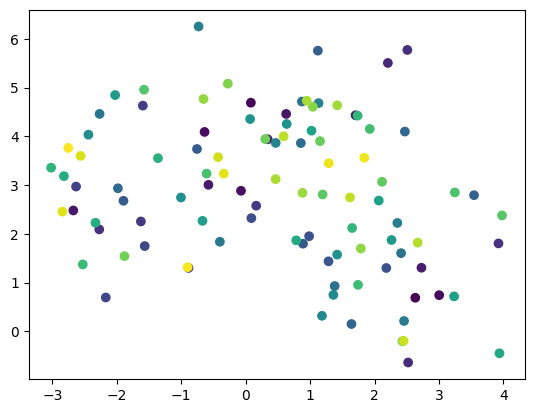

In [22]:
import matplotlib.pyplot as plt

y = model.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y)